# Analyze A/B Test Results



## Table of Contents
- [Introduction](#intro)
- [Part I - Descriptive Statistics](#descriptive)
- [Part II - Probability](#probability)
- [Part III - Experimentation](#experimentation)


<a id='intro'></a>
### Introduction

A/B tests are very commonly performed by data analysts and data scientists.  For this project, I worked to understand the results of an A/B test run by an e-commerce website.  My goal is to work through this notebook to help the company understand if they should implement the new page, keep the old page, or perhaps run the experiment longer to make their decision.

<a id='descriptive'></a>
#### Part I - Descriptive Statistics

To get started, let's import our libraries.

In [37]:
import pandas as pd
import numpy as np
# import random
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

np.random.seed(0)

In [38]:
# Read in the dataset and take a look at the top few rows here.
df = pd.read_csv('ab_data.csv')
df.head()

,country,group,converted
0,UK,control,0
1,US,treatment,1
2,UK,treatment,0
3,UK,control,0
4,UK,treatment,0


`b)` Used the below cell to find the number of rows in the dataset.

In [39]:
print(f'Number of rows in the dataset: {df.shape[0]} rows.')

Number of rows in the dataset: 69889 rows.


`c)` The proportion of users converted.

In [40]:
df.query('converted == 1').country.count() / df.country.count()


np.float64(0.13047832992316388)

In [41]:
print('Mean values for the converted users: ',round(df.mean(numeric_only=True).values[0],5))


Mean values for the converted users:  0.13048


In [42]:
df.group.value_counts()

,count
group,
treatment,35211
control,34678


`d)` Do any of the rows have missing values, Answer:

In [43]:
df.isnull().sum()

,0
country,0
group,0
converted,0


>**No missing values.**

`e)` How many customers are from each country, Answer:

In [44]:
# number of visitors from each country - pull the necessary code from the next cell to provide just the counts
df['country'].value_counts()

,count
country,
US,48850
UK,17551
CA,3488


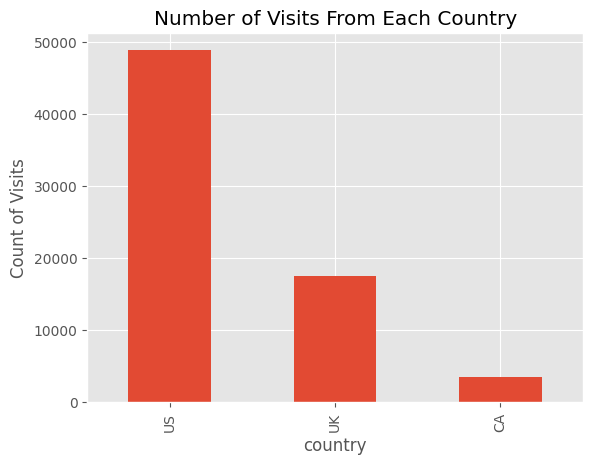

In [45]:
# bar chart of results - this part is done for you
df['country'].value_counts().plot(kind='bar');
plt.title('Number of Visits From Each Country');
plt.ylabel('Count of Visits');
plt.show();

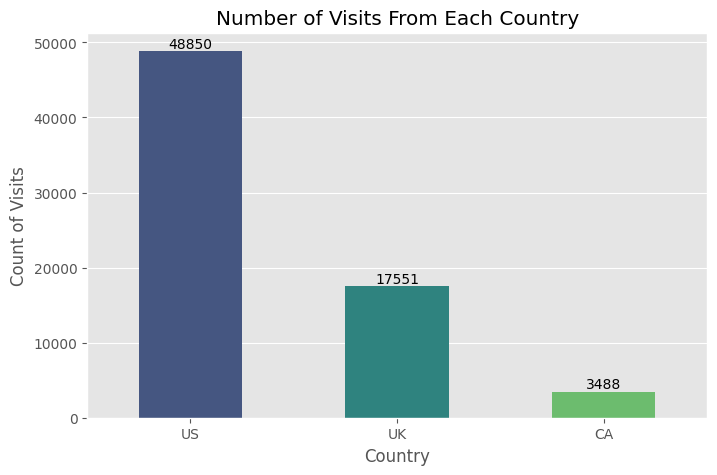

In [46]:
fig,ax = plt.subplots(figsize=(8,5))
ax = sns.barplot(x=df['country'].value_counts().index, y=df['country'].value_counts().values, width=0.5, palette='viridis', hue= df['country'].value_counts().index)
plt.xlabel('Country')
plt.ylabel('Count of Visits')
plt.title('Number of Visits From Each Country')

# Add numbers above each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.show();

`f)` Recognize that all of your columns are of a **categorical data type** with the exception of one.  Which column is not **categorical**?

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69889 entries, 0 to 69888
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   country    69889 non-null  object
 1   group      69889 non-null  object
 2   converted  69889 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ MB


>**converted** column is a binary column (0 or 1) _numeric column_, but it points to categorical data.

`g)` What are the possible values of the `converted` column?  Does it make sense that these values are the only possible values? Why or why not? - Answer:


In [48]:
df['converted'].value_counts()


,count
converted,
0,60770
1,9119


>The possible values for the **converted** column are 0 and 1. And yes these values are the only possible values for this column. We only have two types converted users: those who converted (1) and those who did not convert (0).


<a id='probability'></a>
#### Part II - Probability

Now that you have had a chance to learn more about the dataset, let's look more at how different factors are related to `converting`.

`a)` What is the probability of an individual converting regardless of the page they receive or the country they are from? Simply, what is the chance of conversion in the dataset? -Answer:

In [49]:
print('Probability of converting regardless of page.')
df.query('converted == 1').country.count() / df.country.count()

Probability of converting regardless of page.


np.float64(0.13047832992316388)

`b)` Given that an individual was in the `control` group, what is the probability they converted? -Answer:

In [50]:
print('Given that an individual was in the control group, the probability of converting.')
df.query('group == "control"')['converted'].mean()

Given that an individual was in the control group, the probability of converting.


np.float64(0.1052540515600669)

`c)` Given that an individual was in the `treatment` group, what is the probability they converted?  -Answer:

In [51]:
# df.query('group == "treatment"')['converted'].mean()
print('Given that an individual was in the treatment group, the probability of converting.')
df[df['group'] == 'treatment']['converted'].mean()


Given that an individual was in the treatment group, the probability of converting.


np.float64(0.15532078043793132)

`d)` Do we see evidence that the treatment is related to higher `converted` rates? -Answer:

>Yes, the treatment group shows a higher conversion rate (≈ 15.5%) than the control group (≈ 10.5%). We still need hypothesis testing to know if this difference is statistically significant.

`e)` What is the probability that an individual was in the `treatment`? -Answer:

In [52]:
# df[df['group'] == 'treatment'].mean(numeric_only=True)
print('The probability that a customer was in the treatment group:')
df.query('group == "treatment"').country.count() / df.country.count()


The probability that a customer was in the treatment group:


np.float64(0.5038131894861853)

In [53]:
# df.groupby('group').describe()

`f)` What is the probability that an individual was from US `CA`? -Answer:

In [54]:
df.query('country == "CA"').country.count() / df.country.count()


np.float64(0.04990771079855199)

`g)` Given that an individual was in the `US`, what was the probability that they `converted`?

$P(\text{converted} == 1|\text{country} ==\text{"US"})$



In [55]:
df.query('country == "US"')['converted'].mean()

np.float64(0.13277379733879222)

`h)` Given that an individual was in the `UK`, what was the probability that they `converted`?

$P(\text{converted} == 1|\text{country} ==\text{"UK"})$

In [56]:
df.query('country == "UK"')['converted'].mean()

np.float64(0.12512107572218106)

In [57]:
df.query('country == "CA"')['converted'].mean()

np.float64(0.1252866972477064)

`i)` Do you see evidence that the `converted` rate might differ from one country to the next? -Answer:

>No, I don't see a big evidance of changing country affects the converted rate,  because the three countries almost have very similar converted rates.

`j)` **Depending on the below steps, There is no obivious interaction between how country and treatment impact conversion.**

In [58]:
# # Method 1  - explicitly calculate each probability
# print(df.query('country == "US" and group == "control" and converted == 1').shape[0]/df.query('country == "US" and group == "control"').shape[0])
# print(df.query('country == "US" and group == "treatment" and converted == 1').shape[0]/df.query('country == "US" and group == "treatment"').shape[0])

In [59]:
# calculate using `groupby`
# US
df.query('country == "US"').groupby('group')['converted'].mean()

,converted
group,
control,0.107314
treatment,0.157769


In [60]:
# UK
df.query('country == "UK"').groupby('group')['converted'].mean()

,converted
group,
control,0.101649
treatment,0.148698


In [61]:
# CA
df.query('country == "CA"').groupby('group')['converted'].mean()

,converted
group,
control,0.094474
treatment,0.154017


##### Completed Table
|             | US          | UK          | CA          |
| ----------- | ----------- | ----------- | ----------- |
| Control     | 10.7%       |  10.1%          |  09.4%          |
| Treatment   | 15.8%       |  14.8%          |  15.4%          |




<a id='experimentation'></a>
### Part III - Experimentation

Consider we need to make the decision just based on all the data provided.  If we want to assume that the control page is better unless the treatment page proves to be definitely better at a Type I error rate of 5%, we state your null and alternative hypotheses in terms of **$p_{control}$** and **$p_{treatment}$** as:  

$H_{0}: p_{control} >= p_{treatment}$

$H_{1}: p_{control} < p_{treatment}$

Which is equivalent to:

$H_{0}: p_{treatment} - p_{control} <= 0$

$H_{1}: p_{treatment} - p_{control} > 0$


Where  
* **$p_{control}$** is the `converted` rate for the control page
* **$p_{treatment}$** `converted` rate for the treatment page

**Note for this experiment we are not looking at differences associated with country.**

`a)` The **convert rate** for $p_{treatment}$ under the null.  The **convert rate** for $p_{control}$ under the null. The sample size for the `control` and the sample size for the `treatment` are from the original dataset.

In [62]:
p_control_treatment_null  = df['converted'].mean()
n_treatment = df.query('group == "treatment"').shape[0]
n_control = df.query('group == "control"').shape[0]

p_control_treatment_null, n_treatment, n_control

(np.float64(0.13047832992316388), 35211, 34678)

`b)` Used the results from part `a)` to simulate `n_treatment` transactions with a convert rate of `p_treatment_null`.  Store these $n_{treatment}$ 1's and 0's in a `list` of **treatment_converted**.

In [63]:
# Use the results from part `a)` to simulate `n_treatment` transactions with a convert rate of `p_treatment_null`.  Store these $n_{treatment}$ 1's and 0's in a `list` of **treatment_converted**.  It should look something like the following (the 0's and and 1's **don't** need to be the same): `[0, 0, 1, 1, 0, ....]`
treatment_converted = np.random.binomial(1, p_control_treatment_null, n_treatment)
treatment_converted


array([0, 0, 0, ..., 0, 1, 0])

`c)` Used the results from part `a)` to simulate `n_control` transactions with a convert rate of `p_control_null`.  Store these $n_{treatment}$ 1's and 0's in a `list` of **control_converted**.

In [64]:
# Use the results from part a) to simulate n_control transactions with a convert rate of p_control_null. Store these  ntreatment  1's and 0's in a list of control_converted. It should look something like the following (the 0's and and 1's don't need to be exactly the same): [0, 0, 1, 1, 0, ....]
control_converted = np.random.binomial(1, p_control_treatment_null, n_control)
control_converted

array([0, 0, 0, ..., 0, 0, 0])

`d)` Found the estimate for $p_{treatment}$ - $p_{control}$ under the null using the simulated values from part `(b)` and `(c)`.

In [65]:
#  Find the estimate for  ptreatment  -  pcontrol  under the null using the simulated values
p_control_null = control_converted.mean()
p_treatment_null = treatment_converted.mean()

print(f"p_treatment_null: {p_treatment_null}, p_control_null: {p_control_null}")

p_treatment_null: 0.1296469853170884, p_control_null: 0.12794855528000462


_The reason why our simulated treatment conversion rate ($\hat{p}_{treatment, null}$) is slightly higher than the simulated control conversion rate ($\hat{p}_{control, null}$) in a single simulation run is due to **Sampling Variability (or Random Chance)**._

`e)` Simulated 10000 $p_{treatment}$ - $p_{control}$ values using this same process as `b)`- `d)` similarly to the one you calculated in parts **a. through g.** above.  Stored all 10000 values in an numpy array called **p_diffs**.

In [66]:
p_diffs = []

# It's better practice to use a higher number of simulations for a smoother distribution.
num_simulations = 10_000

# p_pooled is the overall conversion rate
p_pooled = df['converted'].mean()
n_treatment = df.query('group == "treatment"').shape[0]
n_control = df.query('group == "control"').shape[0]

for _ in range(num_simulations):
    # 1. Simulate new sample for treatment (with pooled rate)
    sim_treatment_conversions = np.random.binomial(n_treatment, p_pooled)
    sim_p_treatment = sim_treatment_conversions / n_treatment

    # 2. Simulate new sample for control (with pooled rate)
    sim_control_conversions = np.random.binomial(n_control, p_pooled)
    sim_p_control = sim_control_conversions / n_control

    # 3. Calculate the difference for this simulation run
    p_diff = sim_p_treatment - sim_p_control
    p_diffs.append(p_diff)

p_diffs = np.array(p_diffs)

`f)` Ploted a histogram of the **p_diffs**.

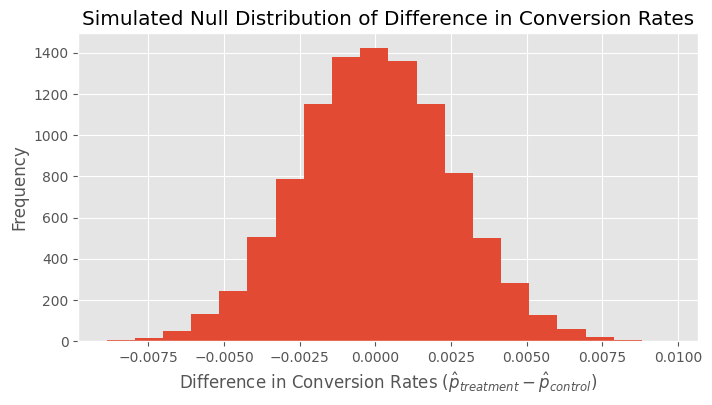

In [67]:
p_diffs = pd.Series(p_diffs)
p_diffs.hist(bins=20, figsize=(8,4))

plt.title('Simulated Null Distribution of Difference in Conversion Rates')
plt.xlabel('Difference in Conversion Rates ($\hat{p}_{treatment} - \hat{p}_{control}$)')
plt.ylabel('Frequency')
plt.show()

`g)` Proportion of the **p_diffs** are greater than the difference observed between `treatment` and `control` in `df` steps.

In [68]:

control_convertion_rate = df.query('group == "control"')['converted'].mean()
treatment_convertion_rate = df.query('group == "treatment"')['converted'].mean()

obs_diff = treatment_convertion_rate - control_convertion_rate

print(f'treatment convertion rate: {treatment_convertion_rate:0.5f}\ncontrol convertion rate: {control_convertion_rate:0.5f}')
print (f'Delta in Treatment vs. Control Conversi Rate: {obs_diff:0.5f}')

p_value = (p_diffs > obs_diff).mean()
print(f'p_value: {p_value:0.5f}')



treatment convertion rate: 0.15532
control convertion rate: 0.10525
Delta in Treatment vs. Control Conversi Rate: 0.05007
p_value: 0.00000


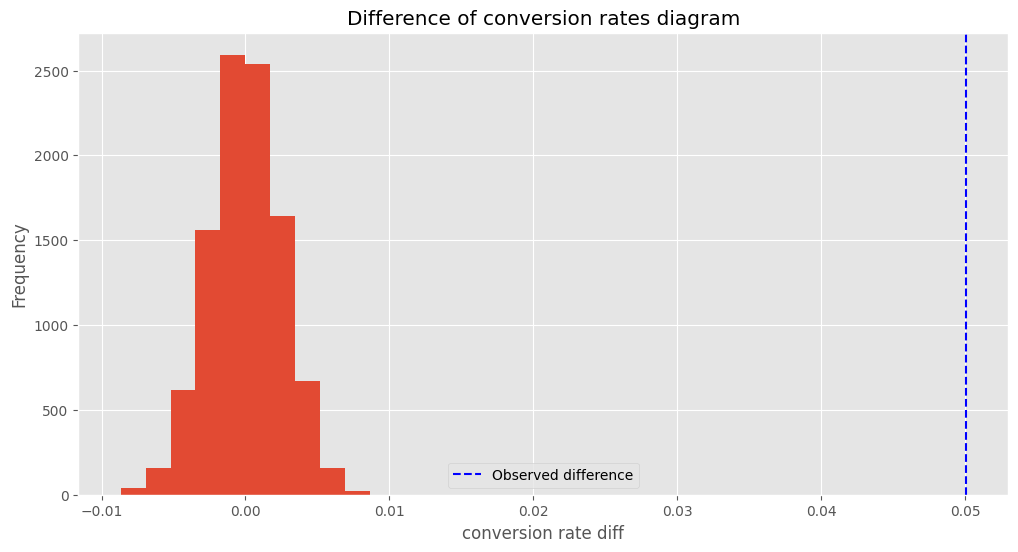

In [69]:
# make mean equals zero
plt.figure(figsize=(12,6))
null_val = np.random.normal(0, p_diffs.std(), p_diffs.size)
plt.hist(null_val)
plt.axvline(x=obs_diff, color='b', linestyle='--', label="Observed difference")
plt.xlabel('conversion rate diff')
plt.ylabel('Frequency')
plt.title('Difference of conversion rates diagram')
plt.legend()
plt.show();

In [70]:
if (p_diffs > obs_diff).mean() > 0.05:
    print('We do not reject the null hypothesis.')
else:
    print('We reject the null hypothesis.')

We reject the null hypothesis.


## Conclusion

**0% is the proportion of the p_diffs that are greater than the actual difference observed in ab_data.csv. In scientific studies this value is also called p-value. This value means that we can reject the null hypothesis and that we do have sufficient evidence that the new_page has a higher conversion rate than the old_page.**